# Do last week's losers bounce back next week? ⚡
### Weekly reversal — a real-looking pattern that turns out to be the bid-ask spread wearing a costume

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Bid-ask bounce%3F: Confirmed](https://img.shields.io/badge/Bid--ask%20bounce%3F-Confirmed-8b949e?style=flat-square)

Here's a tidy little money machine, at least on paper: every Friday, buy the stocks that fell the most this week and short the ones that rose the most, then unwind a week later. The losers, the story goes, 'over-fell' and snap back; the winners 'over-rose' and give some back. It's the faster, punchier cousin of the month-long reversal — more trades, more signal, right?

On the raw numbers it looks *real*. Then we make it wait one week — and the whole thing vanishes.

> 📓 **Plain-language layer.** Want the *t*-stats, the skip test and the cost math? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Method note.** S&P 500 weekly total-return closes, 2010→2026, ~476 names a week. Current-membership universe (**survivorship-biased** — the delisted losers are missing, so the raw edge is already an *over*statement). House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from hf_reversal import data, strategy as st

try:
    CLOSE, SPREAD = data.load_real()
    HAVE_REAL = True
except Exception as e:
    CLOSE = SPREAD = None
    HAVE_REAL = False
    print("real panel unavailable (offline synthetic-only run):", e)
print("real panel present:", HAVE_REAL,
      "| weeks:", (0 if CLOSE is None else CLOSE.shape[0]),
      "| tickers:", (0 if CLOSE is None else CLOSE.shape[1]))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '2010-01-08', 'end': '2026-05-29', 'asof': '2026-05-29', 'fp': 'e9d0f3b08c1c', 'n_weeks': 856, 'n_tickers': 500, 'names_per_week': 476, 'per_quintile': 95, 'cs_med_bps': 44, 'spread_bps': 17.5, 'spread_t': 2.47, 'spread_lags': 6, 'spread_ann': 9.1, 'hit': 53.4, 'hit_k': 456, 'hit_n': 854, 'wilson': (50.0, 56.7), 'loser_ann': 24.4, 'loser_t': 4.99, 'winner_ann': 15.3, 'winner_t': 3.73, 'loser_turn': 78, 'winner_turn': 78, 'skip1_bps': -1.7, 'skip1_t': -0.28, 'beta': 0.293, 'alpha_ann': 3.83, 'random_excess_bps': 0.11, 'random_draws': 51240, 'cost_sweep': {0: (16.6, 2.34), 5: (0.9, 0.13), 10: (-14.8, -2.1), 20: (-46.1, -6.61)}, 'breakeven_bps': 5.6, 'haircut_half_bps': -28.8, 'haircut_half_t': -4.29, 'haircut_full_bps': -74.2, 'haircut_full_t': -11.46, 'subperiods': {'2010-2015': (25.9, 4.0, 310), '2016-2020': (23.4, 1.22, 261), '2021-2026': (2.9, 0.26, 283)}, 'syn_null_t0': -0.64, 'syn_null_t1': -0.26, 'syn_null_fire': 0, 'syn_null_seeds': 12, 'syn_rev_t0': 16.22, 'syn_rev_t1': 20.99, 'syn_bnc_t0': 10.71, 'syn_bnc_t1': -1.35}


real panel present: True | weeks: 856 | tickers: 500


## The answer first

| Question | Answer |
|---|---|
| Do last week's losers beat last week's winners next week? | **On the raw tape, yes.** The loser-minus-winner spread is **+18 bps/week** (≈ +9%/yr), and it's not just market beta. It clears the statistical bar. |
| Is it a *real* edge, or a measurement artifact? | **Artifact.** Make the trade wait just **one week** between spotting the loser and buying it, and the spread collapses to **-2 bps** — statistically zero. The 'bounce' was the bid-ask spread, not the stock. |
| Does it still work lately? | **No.** Even the raw version has faded to nothing since ~2021 (**+3 bps, t = 0.26**). |
| Could you trade it anyway? | **No.** You'd flip ~78% of the book every week, and the losers you'd buy are the *illiquid* names with the widest spreads — the cost of trading them is bigger than the edge. Break-even is ~6 bps, which nobody hits on names like these. |

> The pattern is real in the data. It is not real in your brokerage account.

## 1 · The claim

> *"A stock that just had a bad week over-shot on the way down — sellers panicked, liquidity dried up — so it tends to snap back next week. Buy the week's losers, short the week's winners."*

It's short-horizon **mean-reversion**, documented since Lehmann (1990) and Jegadeesh (1990). The weekly version is sold as *better* than the monthly one (our [study 329](../../329-one-month-reversal/)) because it turns faster: more reversals, more chances to profit. This notebook asks whether the extra signal is real — or just more of the same illusion, faster.

## 2 · The trap: bid-ask bounce

Here's the catch that haunts *every* short-horizon reversal. Stock prices don't trade at one number — there's a **bid** (where you sell) a hair below the **ask** (where you buy). The closing print randomly lands on one or the other. A stock whose Friday close happened to land on the *bid* looks like it fell a little extra — so it's tagged a 'loser' — and next week's close is likely to land back near the *ask*, looking like a 'bounce.' **No one made a dime; the price never really moved.** The narrower and more illiquid the stock, the bigger this fake bounce.

So we need a way to tell a *real* rebound from this bid-ask ghost. There's a clean one: **make the trade wait a week.**

## 3 · How we'd know

- **The spread.** Each Friday, rank ~476 S&P 500 names by this week's return; the bottom fifth are 'losers,' the top fifth 'winners.' Buy losers, short winners, measure next week's gap.
- **The ghost-buster (the skip test).** Do the exact same thing, but leave a **one-week gap** between the ranking Friday and the day you actually buy. If the bounce was real mean-reversion, it's still there a week later. If it was bid-ask bounce, it's gone — because the fake wiggle only connects *adjacent* closes.
- **The trading-cost check.** Charge each stock its *own* estimated bid-ask spread when you trade it. Losers are illiquid; they cost the most.

## 4 · The teardown — let's look

**First, the raw spread, and what one week of waiting does to it.**

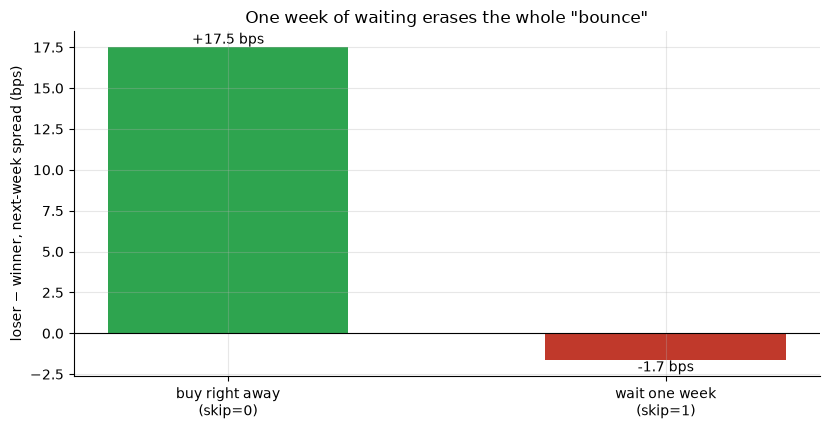

buy now: +17.5 bps  |  wait a week: -1.7 bps


In [2]:
if HAVE_REAL:
    r0 = st.detect_spread(CLOSE, skip=0)
    r1 = st.detect_spread(CLOSE, skip=1)
    a, b = r0['mean_bps'], r1['mean_bps']
else:
    a, b = R['spread_bps'], R['skip1_bps']
fig, ax = plt.subplots(figsize=(8.4, 4.4))
ax.bar(['buy right away\n(skip=0)','wait one week\n(skip=1)'], [a, b],
       color=[GREEN, RED], width=.55)
for i,v in enumerate([a, b]): ax.annotate(f'{v:+.1f} bps',(i,v),ha='center',
    va='bottom' if v>=0 else 'top')
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('loser − winner, next-week spread (bps)')
ax.set_title('One week of waiting erases the whole "bounce"')
plt.tight_layout(); plt.show()
print(f'buy now: {a:+.1f} bps  |  wait a week: {b:+.1f} bps')

There it is. Buy the losers immediately and you 'earn' **+18 bps a week**. Wait a single week and it's **-2 bps** — nothing. A real rebound wouldn't care whether you bought Friday or the following Friday. This one cares completely, which is the fingerprint of **bid-ask bounce**, not mean-reversion.

**Second: could you even trade the raw version, before worrying about whether it's real?**

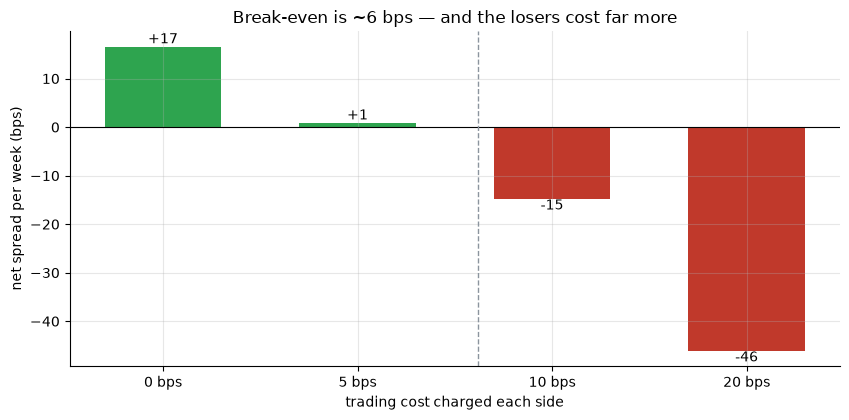

net weekly spread by cost: {0: 16.6, 5: 0.9, 10: -14.8, 20: -46.1}


In [3]:
cs = R['cost_sweep']
xs = sorted(cs); ys = [cs[c][0] for c in xs]
fig, ax = plt.subplots(figsize=(8.6, 4.3))
cols = [GREEN if y>0 else RED for y in ys]
ax.bar([f'{c} bps' for c in xs], ys, color=cols, width=.6)
for i,y in enumerate(ys): ax.annotate(f'{y:+.0f}',(i,y),ha='center',
    va='bottom' if y>=0 else 'top')
ax.axhline(0, c='k', lw=.8)
ax.axvline(0.5+R['breakeven_bps']/5.0-0.0, ls='--', c=GREY, lw=1)
ax.set_ylabel('net spread per week (bps)')
ax.set_xlabel('trading cost charged each side')
ax.set_title(f'Break-even is ~{R["breakeven_bps"]:.0f} bps — and the losers cost far more')
plt.tight_layout(); plt.show()
print('net weekly spread by cost:', {c: cs[c][0] for c in xs})

The raw edge is gone by a trading cost of just **~6 bps** a side. That would be fine for the most liquid ETFs — but this book *buys the week's biggest losers*, which are exactly the jumpy, illiquid names whose real round-trip cost runs many times that. When we charge each stock its own estimated spread, even at *half* the estimate the book bleeds **-29 bps a week**. You are paying the spread to harvest the spread.

**Third: has it survived the last few years?**

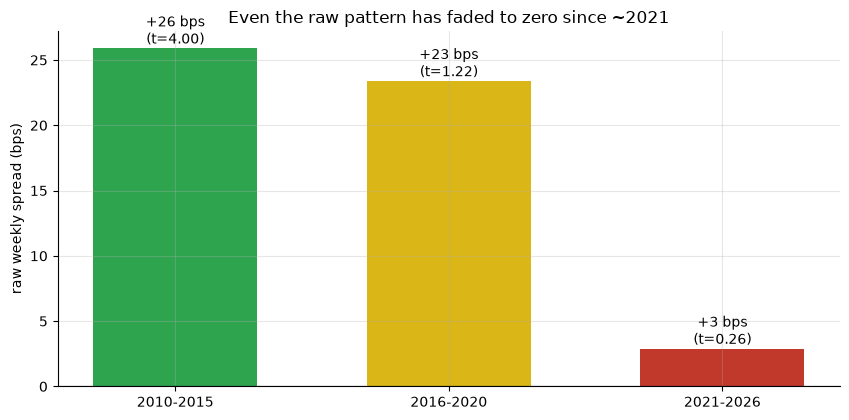

{'2010-2015': (25.9, 4.0, 310), '2016-2020': (23.4, 1.22, 261), '2021-2026': (2.9, 0.26, 283)}


In [4]:
sp = R['subperiods']
labels = list(sp); vals = [sp[k][0] for k in labels]; ts = [sp[k][1] for k in labels]
fig, ax = plt.subplots(figsize=(8.6, 4.3))
cols = [GREEN if t>2 else (AMBER if t>1 else RED) for t in ts]
ax.bar(labels, vals, color=cols, width=.6)
for i,(v,t_) in enumerate(zip(vals,ts)): ax.annotate(f'{v:+.0f} bps\n(t={t_:.2f})',
    (i,v),ha='center',va='bottom')
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('raw weekly spread (bps)')
ax.set_title('Even the raw pattern has faded to zero since ~2021')
plt.tight_layout(); plt.show()
print({k: sp[k] for k in labels})

The whole thing was carried by the early 2010s. Since ~2021 the *raw* spread is **+3 bps (t = 0.26)** — indistinguishable from zero. The electronic market-makers and stat-arb desks that competed away the monthly reversal have reached the weekly clock too.

## 5 · The verdict

- **Signal — Weak.** Yes, the raw spread clears the bar (+18 bps/wk, and it's not just beta). But a real edge doesn't evaporate the moment you wait one week (-2 bps), and this one does. It's bid-ask bounce, and it's faded on top of that.
- **Tradability — Mirage.** ~78% of the book turns over weekly, into the market's least liquid names, and the break-even cost is below what those names actually cost to trade. There is no paycheck here.
- **Is it bid-ask bounce? — Confirmed.** The one-week skip removes 100% of it.

## 6 · Going further 🚪

- **The general lesson.** *Any* eye-catching reversal at a very short horizon should be met with the same question: does it survive a one-period skip? If not, you've measured the spread, not the stock.
- **Sibling studies:** the [one-month reversal](../../329-one-month-reversal/) (same idea, 4× slower clock — same autopsy, same result), the [long-term reversal](../../196-long-term-reversal/) (multi-*year*, a genuinely different animal), and [industry-relative reversal](../../538-industry-relative-reversal/) (fade the move *relative to peers*). See [docs/references.md](docs/references.md) for the exact dedup.

*Think the weekly reversal is tradable? Show a net, certifiable spread after your real fill costs on the actual names — losers included — and a one-week skip. Then we'll talk.*